# Heatmap

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# DATA EXTRACTION
# ---------------------------------------------------------

# Data from Image 1 (image_0ce908.png)
data_1 = {
    "Class": ["Not Enough Information", "Refuted", "Supported"],
    "Precision": [0.70, 0.80, 0.76],
    "Recall":    [0.52, 0.82, 0.89],
    "F1-Score":  [0.60, 0.81, 0.82]
}

# Data from Image 2 (image_0ce982.png)
data_2 = {
    "Class": ["Not Enough Information", "Refuted", "Supported"],
    "Precision": [0.52, 0.82, 0.77],
    "Recall":    [0.66, 0.68, 0.75],
    "F1-Score":  [0.58, 0.74, 0.76]
}

In [ ]:
def plot_single_heatmap(data, title="Classification Report"):
    """
    Generates a high-contrast heatmap for a single classification report.

    Parameters:
    ----------
    data : dict
        A dictionary containing the keys: "Class", "Precision", "Recall", "F1-Score".
    title : str
        The title to display on top of the heatmap.
    """
    # 1. Prepare Data
    if isinstance(data, dict):
        df = pd.DataFrame(data).set_index("Class")
    else:
        df = data

    df = df.T

    # 3. Setup Figure
    plt.figure(figsize=(8, 5)) # Slightly wider to accommodate colorbar

    # 4. Define Style (High Contrast)
    # We set vmin/vmax slightly outside the exact data min/max
    # to ensure the colors look good, but ticks will point to exact stats.
    vmin_tight = 0.50
    vmax_tight = 0.90
    middle = (vmin_tight + vmax_tight)/2
    cmap_choice = "Blues"

    # 5. Plot Heatmap
    ax = sns.heatmap(df, annot=True, cmap=cmap_choice,
                vmin=vmin_tight, vmax=vmax_tight,
                fmt=".2f", linewidths=1.5, linecolor='white',
                annot_kws={"size": 14, "weight": "bold"},
                cbar=True, # Enable colorbar
                cbar_kws={
                    'ticks': [vmin_tight, middle, vmax_tight]
                })

    # 6. Format the Colorbar Labels
    # Access the colorbar object to customize tick labels (optional)
    cbar = ax.collections[0].colorbar
    # cbar.ax.set_yticklabels([f'Min: {val_min:.2f}', f'Med: {val_med:.2f}', f'Max: {val_max:.2f}'])

    # 5. Formatting
    plt.title(title, fontsize=20, pad=20, weight='bold')
    plt.ylabel("") # Remove y-axis label for cleaner look
    plt.xlabel("") # Remove x-axis label for cleaner look
    plt.yticks(rotation=0)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tight_layout()

    # 6. Show Plot
    plt.show()

# BM25

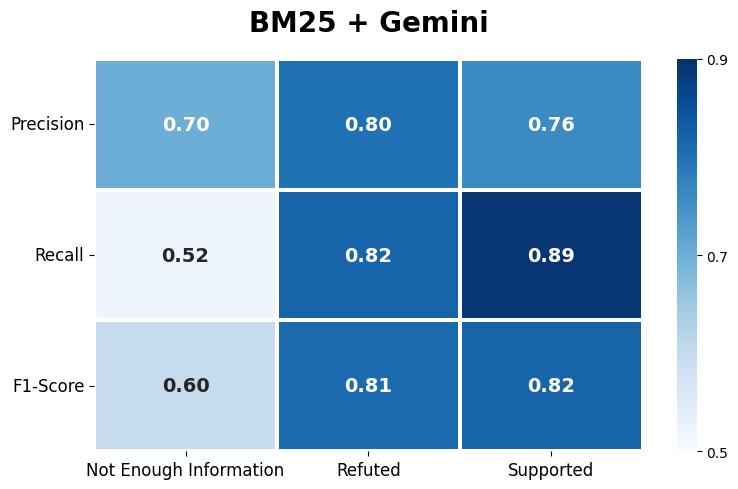

In [ ]:
plot_single_heatmap(data_1, "BM25 + Gemini")

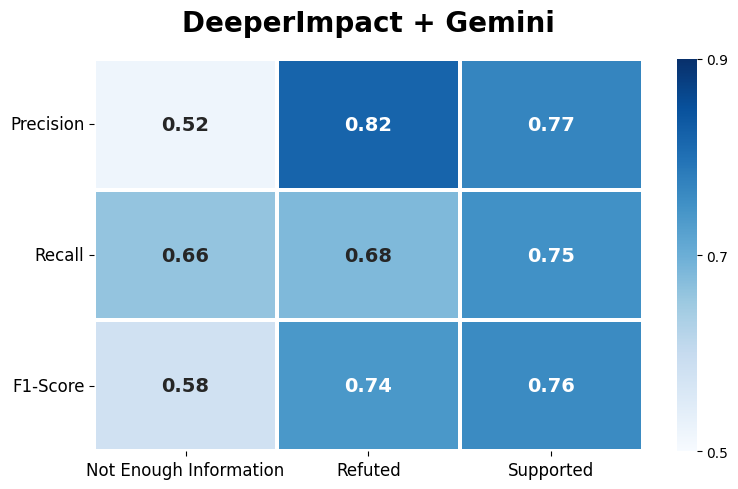

In [ ]:
plot_single_heatmap(data_2, "DeeperImpact + Gemini")

In [ ]:
data_3 = {
    "Class": ["Not Enough Information", "Refuted", "Supported"],
    "Precision": [0.72, 0.80, 0.76],
    "Recall":    [0.52, 0.83, 0.88],
    "F1-Score":  [0.61, 0.82, 0.82]
}

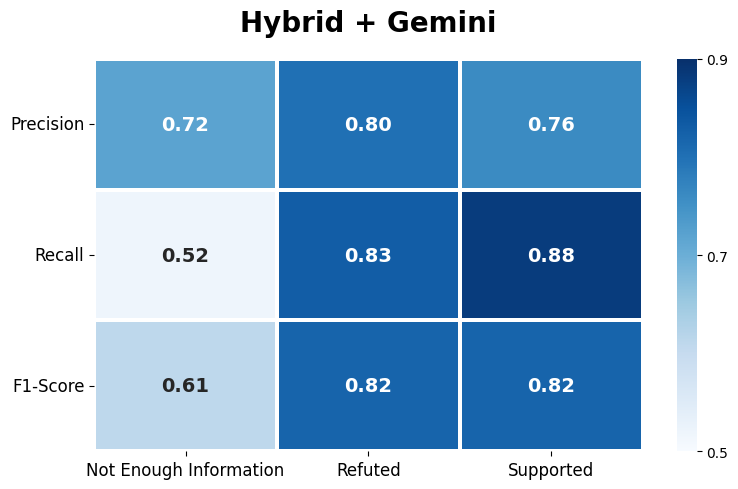

In [ ]:
plot_single_heatmap(data_3, "Hybrid + Gemini")

# Lexical Overlap score

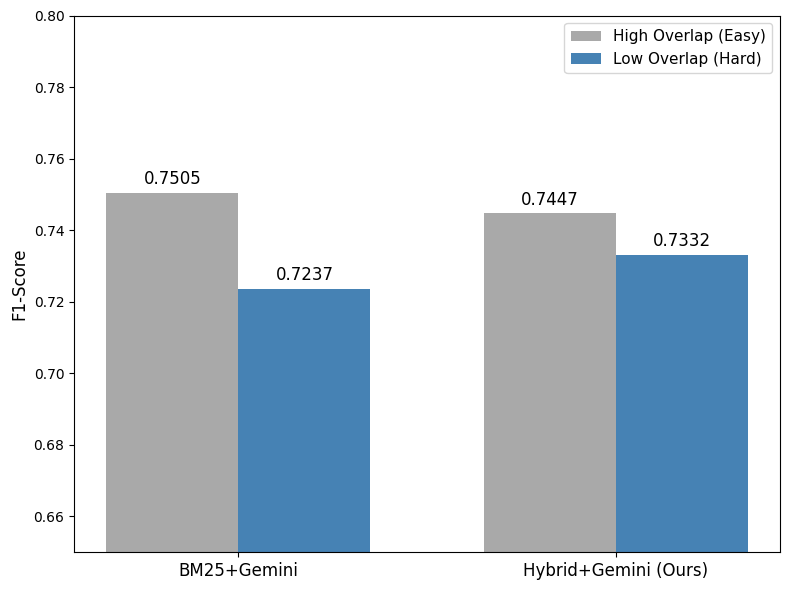

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data reorganization
models = ['BM25+Gemini', 'Hybrid+Gemini (Ours)']
easy_scores = [0.7505, 0.7447]  # High Overlap
hard_scores = [0.7237, 0.7332]  # Low Overlap

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
# Using colors that contrast well. 'Easy' (High Overlap) usually implies better performance, maybe green/blue. 'Hard' maybe orange/red?
# Let's stick to a neutral comparison or consistent coloring.
# Easy = Blue, Hard = Orange is a classic matplotlib default which is distinguishable.
rects1 = ax.bar(x - width/2, easy_scores, width, label='High Overlap (Easy)', color='darkgray')
rects2 = ax.bar(x + width/2, hard_scores, width, label='Low Overlap (Hard)', color='steelblue')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('F1-Score', fontsize=12)
# ax.set_title('Mức độ sụt giảm hiệu năng khi gặp câu hỏi khó (Hard)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0.65, 0.80) # Zoom in

# Add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12)

autolabel(rects1)
autolabel(rects2)

# Draw lines to visualize the drop? Optional but helpful.
# Let's just stick to the bars first as requested.

fig.tight_layout()

# So sánh ViFC vs mMARCO

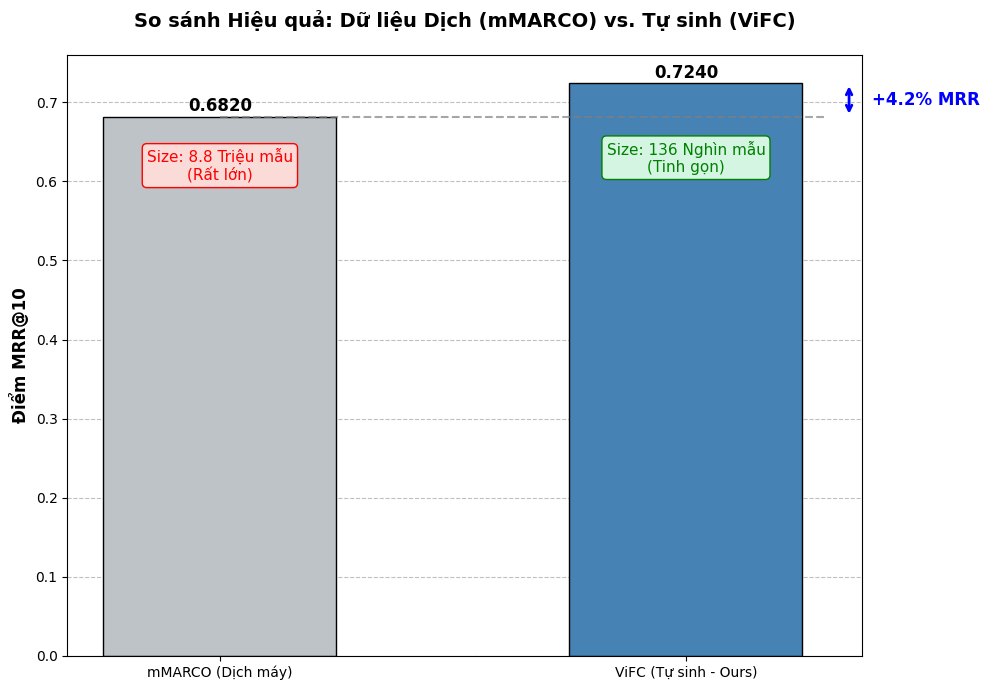

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Dữ liệu ---
models = ['mMARCO (Dịch máy)', 'ViFC (Tự sinh - Ours)']
mrr_scores = [0.6820, 0.7240]
data_sizes = ['8.8 Triệu mẫu', '136 Nghìn mẫu']
colors = ['#bdc3c7', 'steelblue']  # Xám nhạt và Xanh lá (tương tự TikZ)

# --- 2. Thiết lập biểu đồ ---
fig, ax = plt.subplots(figsize=(10, 7))

# Vẽ cột
bars = ax.bar(models, mrr_scores, color=colors, width=0.5, edgecolor='black', linewidth=1)

# --- 3. Tùy chỉnh trục và giới hạn (Zoom effect) ---
# Zoom vào khoảng giá trị để thấy rõ sự chênh lệch
# ax.set_ylim(0.60, 0.76)
ax.set_ylabel('Điểm MRR@10', fontsize=12, fontweight='bold')
ax.set_title('So sánh Hiệu quả: Dữ liệu Dịch (mMARCO) vs. Tự sinh (ViFC)',
             fontsize=14, fontweight='bold', pad=20)

# Lưới nền (Grid)
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.5)
ax.set_axisbelow(True) # Đưa lưới xuống dưới cột

# --- 4. Thêm nhãn giá trị lên đầu cột ---
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- 5. Thêm chú thích về Kích thước Dữ liệu (Data Size Box) ---
# Tạo các hộp text box để hiển thị size dữ liệu
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')

# Box cho mMARCO
ax.text(0, 0.62, f"Size: {data_sizes[0]}\n(Rất lớn)",
        transform=ax.transData, ha='center', va='center',
        fontsize=11, color='red', bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor='red'))

# Box cho ViFC
ax.text(1, 0.63, f"Size: {data_sizes[1]}\n(Tinh gọn)",
        transform=ax.transData, ha='center', va='center',
        fontsize=11, color='green', bbox=dict(boxstyle='round', facecolor='#d5f5e3', edgecolor='green'))

# --- 6. Vẽ mũi tên và nhãn Cải thiện (+4.2%) ---
# Tọa độ đỉnh cột 1 và cột 2
x1, y1 = 1, 0.6820  # Ngang với cột thấp
x2, y2 = 1, 0.7240  # Đỉnh cột cao

# Vẽ đường gióng và mũi tên
ax.annotate('', xy=(1.35, 0.7240), xytext=(1.35, 0.6820),
            arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
ax.text(1.4, 0.703, '+4.2% MRR', color='blue', fontsize=12, fontweight='bold', va='center')

# Vẽ đường kẻ mờ từ đỉnh cột 1 sang để dễ so sánh
ax.hlines(y=0.6820, xmin=0, xmax=1.3, colors='gray', linestyles='dashed', alpha=0.7)

# --- 7. Hiển thị ---
plt.tight_layout()
plt.show()

# Để lưu ảnh, bạn có thể bỏ comment dòng dưới:
# plt.savefig('chart_comparison.png', dpi=300)

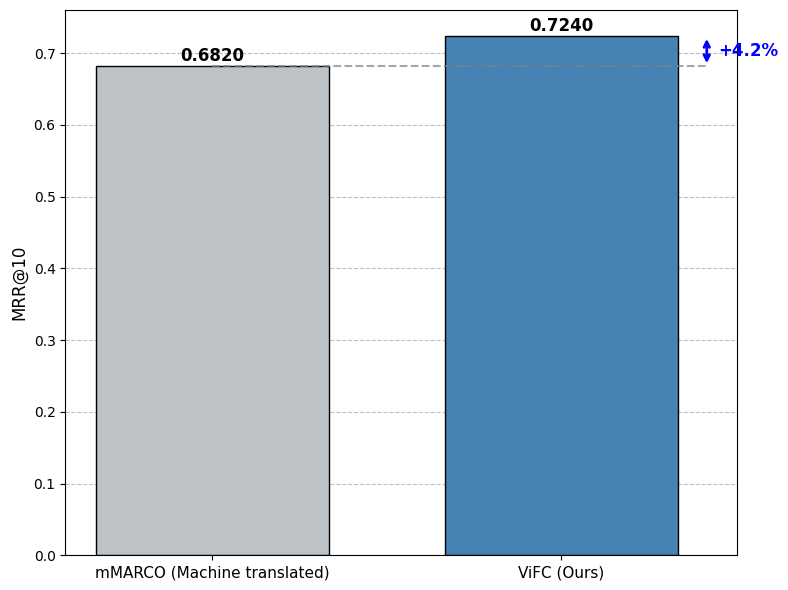

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Dữ liệu ---
models = ['mMARCO (Machine translated)', 'ViFC (Ours)']
mrr_scores = [0.6820, 0.7240]
data_sizes = ['8.8 Triệu mẫu', '136 Nghìn mẫu']
colors = ['#bdc3c7', 'steelblue']

# --- TÙY CHỈNH KHOẢNG CÁCH ---
# Thay vì để tự động, ta set cứng vị trí để chúng gần nhau hơn
# Cột 1 tại 0, Cột 2 tại 0.6 (Gần hơn so với mặc định là 1)
x_positions = [0, 0.6]
bar_width = 0.4  # Độ rộng cột

# --- 2. Thiết lập biểu đồ ---
# Thu nhỏ chiều ngang figure lại một chút cho cân đối
fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ cột tại các vị trí đã định (x_positions)
bars = ax.bar(x_positions, mrr_scores, color=colors, width=bar_width,
              edgecolor='black', linewidth=1)

# --- 3. Tùy chỉnh trục và giới hạn ---
# ax.set_ylim(0.60, 0.76)
ax.set_ylabel('MRR@10', fontsize=12)
# ax.set_title('So sánh Hiệu quả: Dữ liệu Dịch vs. Tự sinh',
#              fontsize=14, fontweight='bold', pad=20)

# Cập nhật nhãn trục X theo vị trí mới
ax.set_xticks(x_positions)
ax.set_xticklabels(models, fontsize=11)

# Lưới nền
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.5)
ax.set_axisbelow(True)

# --- 4. Thêm nhãn giá trị lên đầu cột ---
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- 5. Thêm chú thích Kích thước Dữ liệu (Đã chỉnh tọa độ theo x_positions) ---
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')

# # Box cho mMARCO (vị trí 0)
# ax.text(0, 0.62, f"Size: {data_sizes[0]}\n(Rất lớn)",
#         ha='center', va='center', fontsize=10, color='red',
#         bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor='red'))

# # Box cho ViFC (vị trí 0.6)
# ax.text(0.6, 0.63, f"Size: {data_sizes[1]}\n(Tinh gọn)",
#         ha='center', va='center', fontsize=10, color='green',
#         bbox=dict(boxstyle='round', facecolor='#d5f5e3', edgecolor='green'))

# --- 6. Vẽ mũi tên và nhãn Cải thiện (+4.2%) ---
# Tọa độ tính toán dựa trên x_positions[1] = 0.6
arrow_x = 0.6 + (bar_width / 2) + 0.05 # Lệch sang phải cột 2 một chút
text_x = arrow_x + 0.02

ax.annotate('', xy=(arrow_x, 0.7240), xytext=(arrow_x, 0.6820),
            arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
ax.text(text_x, 0.703, '+4.2%', color='blue', fontsize=12, fontweight='bold', va='center')

# Đường kẻ ngang mờ so sánh
ax.hlines(y=0.6820, xmin=0, xmax=arrow_x, colors='gray', linestyles='dashed', alpha=0.7)

# --- 7. Hiển thị ---
plt.tight_layout()
plt.show()

# Ảnh hưởng của $\alpha$ đến hiệu suất

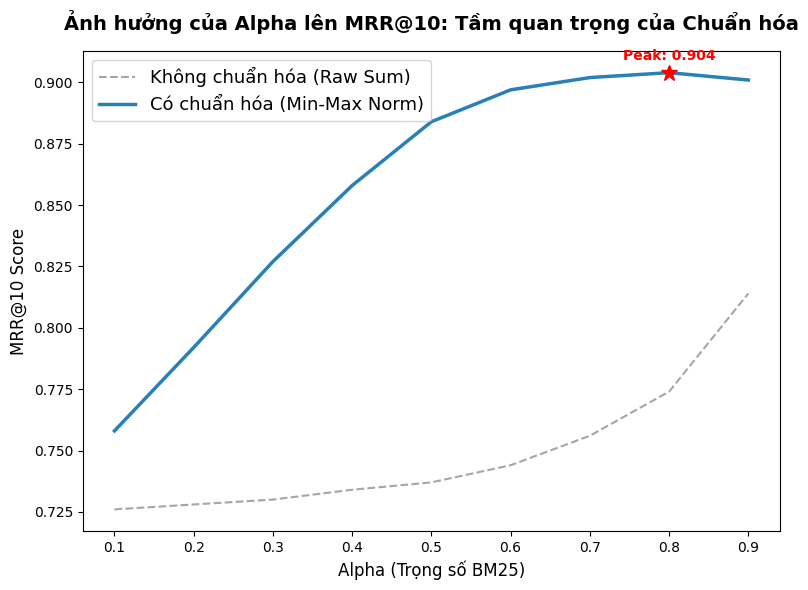

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Dữ liệu trích xuất từ Notebook ---
alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dữ liệu chạy KHÔNG có flag --normalize (Cell output đầu tiên)
mrr_no_norm = [0.726, 0.728, 0.730, 0.734, 0.737, 0.744, 0.756, 0.774, 0.814]

# Dữ liệu chạy CÓ flag --normalize (Cell output thứ hai)
mrr_with_norm = [0.758, 0.792, 0.827, 0.858, 0.884, 0.897, 0.902, 0.904, 0.901]

# --- 2. Vẽ biểu đồ ---
plt.figure(figsize=(8, 6))

# Đường Không chuẩn hóa (Nét đứt, màu xám)
plt.plot(alphas, mrr_no_norm, linestyle='--', color='gray',
         label='Không chuẩn hóa (Raw Sum)', alpha=0.7)

# Đường Có chuẩn hóa (Nét liền, màu xanh, đậm hơn)
plt.plot(alphas, mrr_with_norm, linestyle='-', color='#2980b9',
         linewidth=2.5, label='Có chuẩn hóa (Min-Max Norm)')

# --- 3. Trang trí đơn giản ---
plt.title('Ảnh hưởng của Alpha lên MRR@10: Tầm quan trọng của Chuẩn hóa',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Alpha (Trọng số BM25)', fontsize=12)
plt.ylabel('MRR@10 Score', fontsize=12)
plt.xticks(alphas)
# plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=13)

# Đánh dấu điểm cực đại (Sweet Spot)
max_score = max(mrr_with_norm)
max_alpha = alphas[mrr_with_norm.index(max_score)]
plt.plot(max_alpha, max_score, marker='*', color='red', markersize=12, zorder=10)
plt.text(max_alpha, max_score + 0.005, f'Peak: {max_score}',
         ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

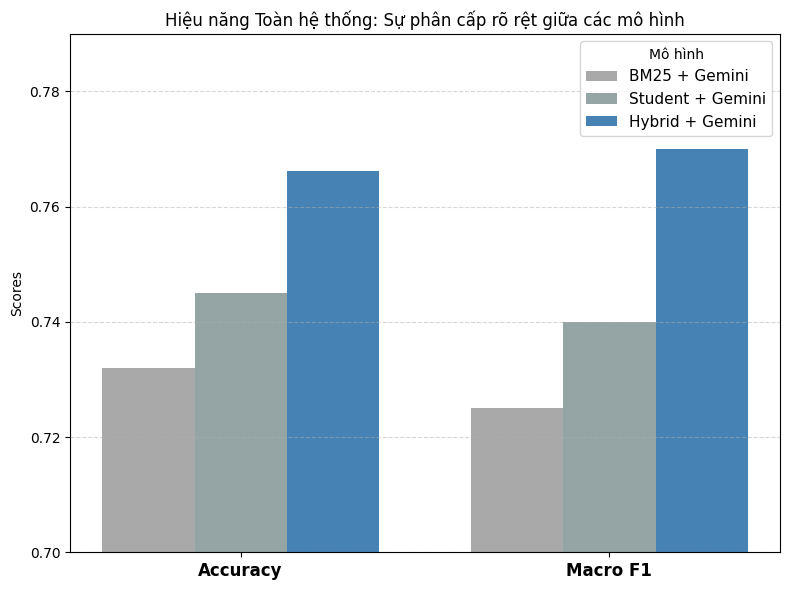

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Dữ liệu ---
metrics = ['Accuracy', 'Macro F1']
# Sắp xếp dữ liệu theo từng mô hình: [Giá trị Accuracy, Giá trị F1]
bm25_scores = [0.7320, 0.7250]      # Baseline (Thấp nhất)
student_scores = [0.7450, 0.7400]   # Student (Trung bình)
hybrid_scores = [0.7662, 0.7700]    # Hybrid (Cao nhất)

# --- 2. Thiết lập vị trí cột ---
x = np.arange(len(metrics))  # Vị trí cho 2 nhóm: Accuracy và Macro F1
width = 0.25  # Độ rộng cột (chia nhỏ để vừa 3 cột trong 1 nhóm)

# --- 3. Vẽ biểu đồ ---
fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ 3 cột liền kề nhau tại mỗi vị trí x
rects1 = ax.bar(x - width, bm25_scores, width, label='BM25 + Gemini', color='darkgray') # Xám (Nền)
rects2 = ax.bar(x, student_scores, width, label='Student + Gemini', color='#95a5a6')   # Xanh dương
rects3 = ax.bar(x + width, hybrid_scores, width, label='Hybrid + Gemini', color='steelblue') # Đỏ (Nổi bật)

# --- 4. Tùy chỉnh ---
ax.set_ylabel('Scores')
ax.set_title('Hiệu năng Toàn hệ thống: Sự phân cấp rõ rệt giữa các mô hình')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontweight='bold', fontsize=12)
ax.legend(title='Mô hình', fontsize=11) # Legend giải thích màu sắc

# Zoom trục Y để thấy rõ bậc thang
ax.set_ylim(0.70, 0.79)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Tổng hợp metric đầu cuối

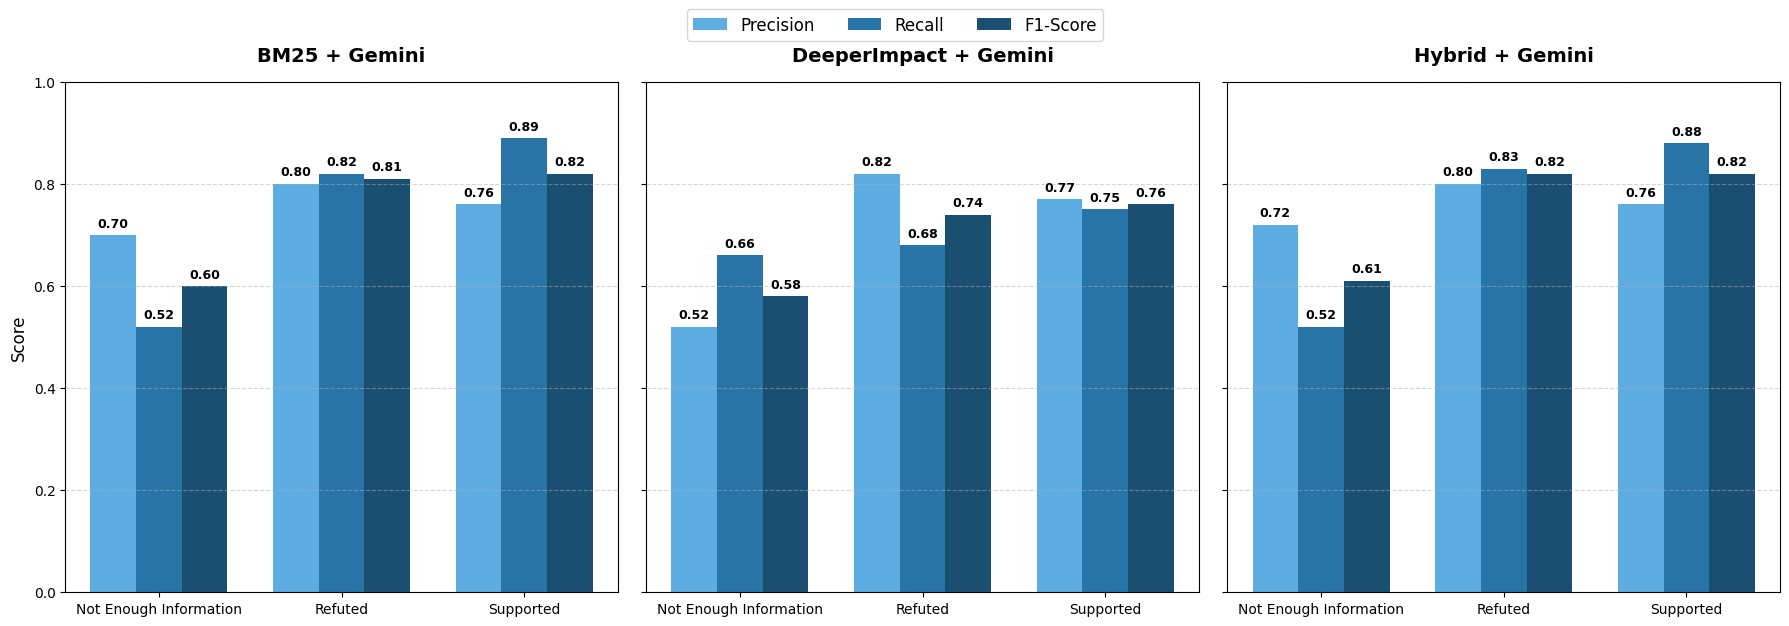

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define the Data ---
categories = ["Not Enough Information", "Refuted", "Supported"]
metrics = ["Precision", "Recall", "F1-Score"]

# Data structure: Model Name -> { Metric -> [Values for categories] }
data = {
    "BM25 + Gemini": {
        "Precision": [0.70, 0.80, 0.76],
        "Recall":    [0.52, 0.82, 0.89],
        "F1-Score":  [0.60, 0.81, 0.82]
    },
    "DeeperImpact + Gemini": {
        "Precision": [0.52, 0.82, 0.77],
        "Recall":    [0.66, 0.68, 0.75],
        "F1-Score":  [0.58, 0.74, 0.76]
    },
    "Hybrid + Gemini": {
        "Precision": [0.72, 0.80, 0.76],
        "Recall":    [0.52, 0.83, 0.88],
        "F1-Score":  [0.61, 0.82, 0.82]
    }
}

# --- 2. Setup the Plot ---
# We'll create 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
bar_width = 0.25
x = np.arange(len(categories))

# Colors for the metrics
colors = ['#5dade2', '#2874a6', '#1b4f72']  # Light to dark blue theme

# --- 3. Loop through Models and Plot ---
for i, (model_name, metrics_data) in enumerate(data.items()):
    ax = axes[i]

    # Plot bars for each metric (Precision, Recall, F1)
    for j, metric in enumerate(metrics):
        # Calculate offset so bars don't overlap
        offset = (j - 1) * bar_width
        bars = ax.bar(x + offset, metrics_data[metric], bar_width, label=metric, color=colors[j])

        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Formatting each subplot
    ax.set_title(model_name, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1.0) # Scale from 0 to 1 for percentages

    # Only show Y-label on the first chart
    if i == 0:
        ax.set_ylabel("Score", fontsize=12)

    # Add gridlines behind bars
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# --- 4. Final Touches ---
# Add a single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=12)

plt.tight_layout()
plt.show()

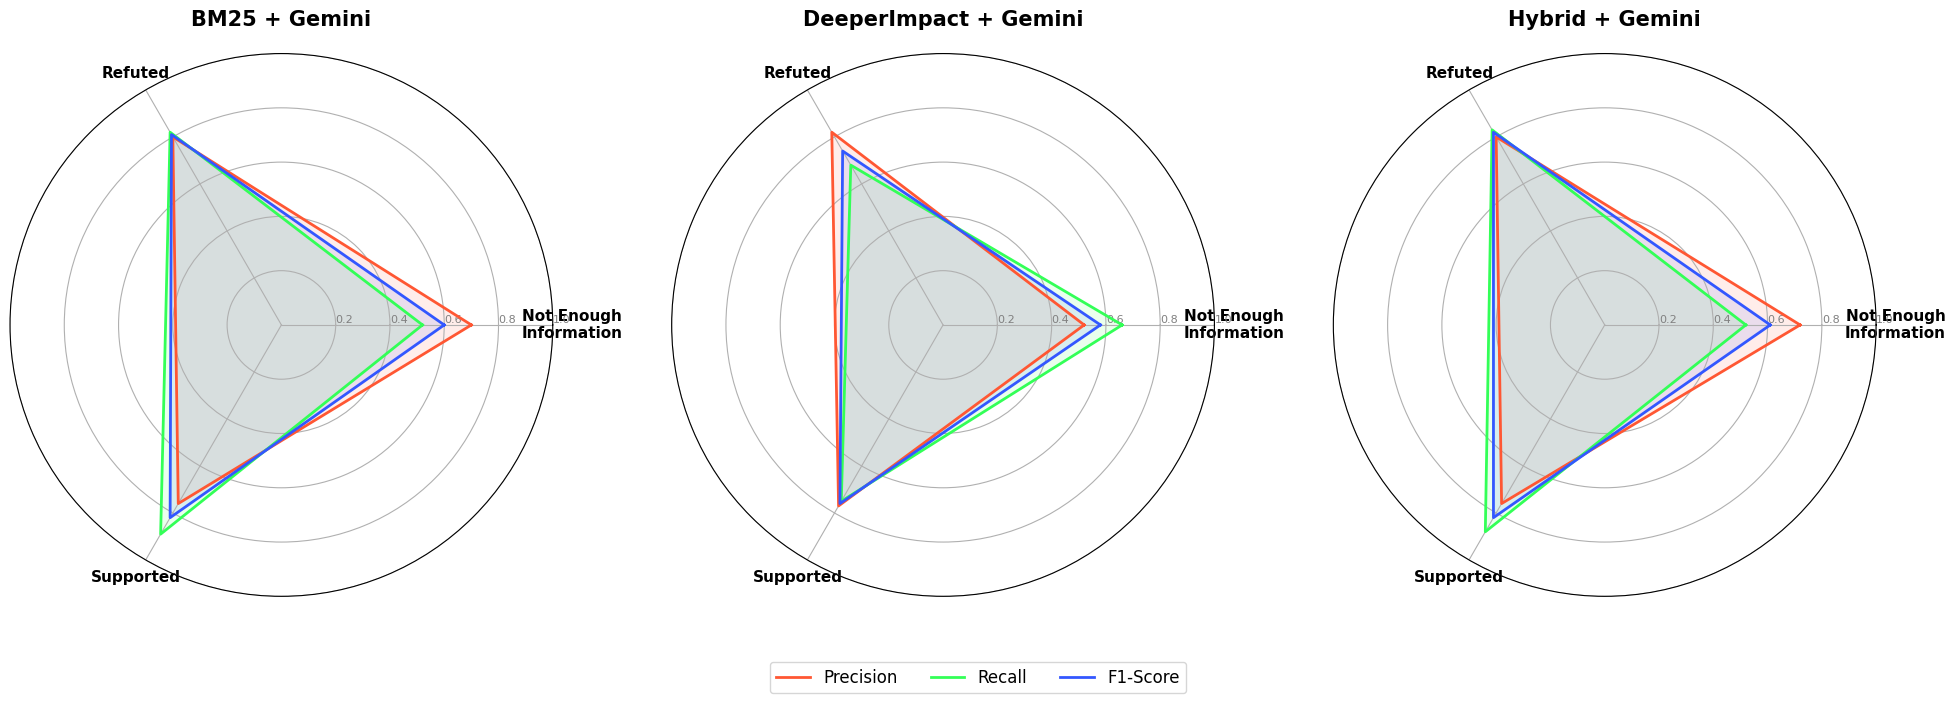

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Setup ---
categories = ["Not Enough\nInformation", "Refuted", "Supported"]
metrics = ["Precision", "Recall", "F1-Score"]

data = {
    "BM25 + Gemini": {
        "Precision": [0.70, 0.80, 0.76],
        "Recall":    [0.52, 0.82, 0.89],
        "F1-Score":  [0.60, 0.81, 0.82]
    },
    "DeeperImpact + Gemini": {
        "Precision": [0.52, 0.82, 0.77],
        "Recall":    [0.66, 0.68, 0.75],
        "F1-Score":  [0.58, 0.74, 0.76]
    },
    "Hybrid + Gemini": {
        "Precision": [0.72, 0.80, 0.76],
        "Recall":    [0.52, 0.83, 0.88],
        "F1-Score":  [0.61, 0.82, 0.82]
    }
}

# --- 2. Chart Configuration ---
N = len(categories)
# Compute angle for each axis
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Close the loop for the plot

fig, axes = plt.subplots(1, 3, figsize=(20, 7), subplot_kw={'projection': 'polar'})

# Styling
colors = ['#FF5733', '#33FF57', '#3357FF']
line_styles = ['-', '-', '-']

# --- 3. Plotting Loop ---
for i, (model_name, metrics_data) in enumerate(data.items()):
    ax = axes[i]

    # Setup the Axis
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11, weight='bold')

    # Setup Y-Axis (Radial)
    ax.set_rlabel_position(0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
    ax.set_ylim(0, 1)

    # Plot Data
    for j, metric in enumerate(metrics):
        values = metrics_data[metric]
        values += values[:1] # Close the loop

        ax.plot(angles, values, linewidth=2, linestyle=line_styles[j], label=metric, color=colors[j])
        ax.fill(angles, values, color=colors[j], alpha=0.1)

    ax.set_title(model_name, size=15, weight='bold', pad=20)

# --- 4. Final Layout ---
# Global Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12, bbox_to_anchor=(0.5, 0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.2) # Make room for legend
plt.show()

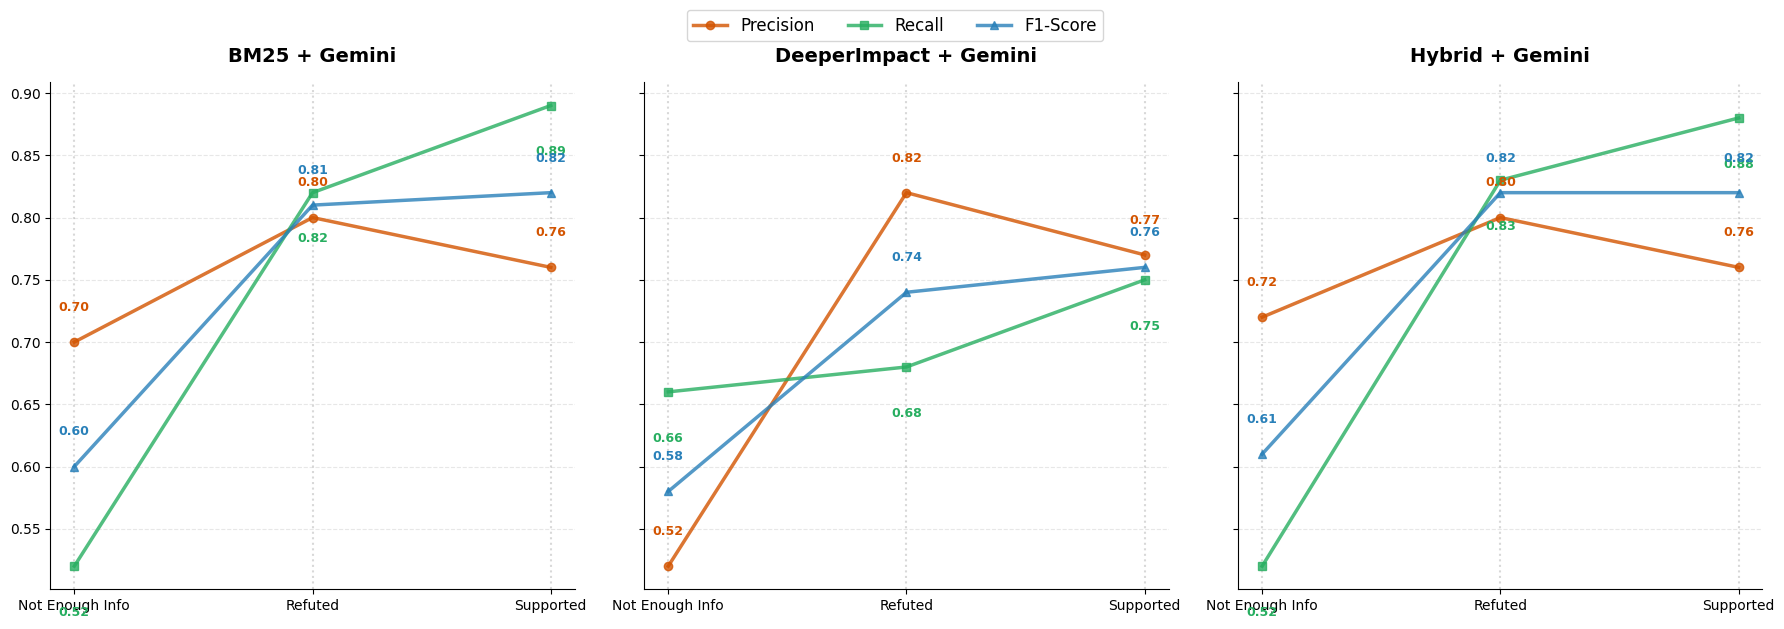

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Data Setup ---
categories = ["Not Enough Info", "Refuted", "Supported"]
metrics = ["Precision", "Recall", "F1-Score"]
colors = ['#d35400', '#27ae60', '#2980b9'] # Burnt Orange, Green, Blue
markers = ['o', 's', '^']

data = {
    "BM25 + Gemini": {
        "Precision": [0.70, 0.80, 0.76],
        "Recall":    [0.52, 0.82, 0.89],
        "F1-Score":  [0.60, 0.81, 0.82]
    },
    "DeeperImpact + Gemini": {
        "Precision": [0.52, 0.82, 0.77],
        "Recall":    [0.66, 0.68, 0.75],
        "F1-Score":  [0.58, 0.74, 0.76]
    },
    "Hybrid + Gemini": {
        "Precision": [0.72, 0.80, 0.76],
        "Recall":    [0.52, 0.83, 0.88],
        "F1-Score":  [0.61, 0.82, 0.82]
    }
}

# --- 2. Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (model_name, metrics_data) in enumerate(data.items()):
    ax = axes[i]

    # Background "Slope" vertical lines
    for x_pos in range(len(categories)):
        ax.axvline(x=x_pos, color='gray', linestyle=':', alpha=0.3)

    # Plot Lines
    for j, metric in enumerate(metrics):
        values = metrics_data[metric]
        ax.plot(categories, values, marker=markers[j], linewidth=2.5,
                label=metric, color=colors[j], alpha=0.8)

        # Add labels near points
        for x_idx, val in enumerate(values):
            # Dynamic offset to prevent text overlap
            offset = 0.025 if j % 2 == 0 else -0.04
            ax.text(x_idx, val + offset, f"{val:.2f}",
                    ha='center', fontsize=9, fontweight='bold', color=colors[j])

    # Styling
    ax.set_title(model_name, fontsize=14, fontweight='bold', pad=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=12)

plt.tight_layout()
plt.show()